## Introduction, Metric, & Best Neighborhood

The Project: The objective of this project is to define the "best" neighborhood in Pittsburgh using a data-driven approach. We define "best" through the lens of "Health & Safety", with our submetrics being obesity rates, median age of death, and number of speed bumps within a specific neighborhood. A great neighborhood should be a space for its residents to live healthy and safe lives. We initially considered metrics concerning population and number of census tracts, but we wanted to choose this metric because on one hand, demographics merely describe a community, whereas health outcomes and safety measures the actual quality of the human experience. We chose this approach to highlight the neighborhoods that don't just house people, but actively extend and protect their lives.

All 3 of our submetrics are from the Western Pennsylvania Regional Data Center (WPRDC). For each, the data was grouped by neighborhood in order to find the averages for each one. We then decided to look at our top 5-10 neighborhoods for each submetric, and whichever neighborhood showed up high on the list for all three submetrics would be deemed the best neighborhood in Allegehny County. Our findings showed that based on these Health and Safety submetrics, North Oakland is the best neighborhood. 

## Average Obesity Rates

In [2]:
import pandas as pd
df = pd.read_csv('obesity-ac-2006-2010censustracts.csv')

# Group by 'City Neighborhood' and calculate the mean estimate of obesity for each neighborhood.
neighborhood_obesity = df.dropna(subset=['City Neighborhood']).groupby('City Neighborhood')['2006-2010 estimate of obesity'].mean().reset_index()
neighborhood_obesity.columns = ['Neighborhood', 'Average Obesity Rate']

# Sort the results by the ascending obesity rate
neighborhood_obesity = neighborhood_obesity.sort_values(by='Average Obesity Rate', ascending=True)

neighborhood_obesity.to_csv('neighborhood_obesity_averages.csv', index=False)

print(neighborhood_obesity)

            Neighborhood  Average Obesity Rate
55         North Oakland              0.104579
56           North Shore              0.121487
77   Squirrel Hill North              0.125941
69             Shadyside              0.127718
19       Central Oakland              0.128668
..                   ...                   ...
83       Terrace Village              0.674103
68           Saint Clair              0.699500
14  California Kirkbride              0.771046
31             Fairywood              0.820311
58     Northview Heights              0.922932

[91 rows x 2 columns]


## Bar chart to show top 5 least obese neighborhoods on average

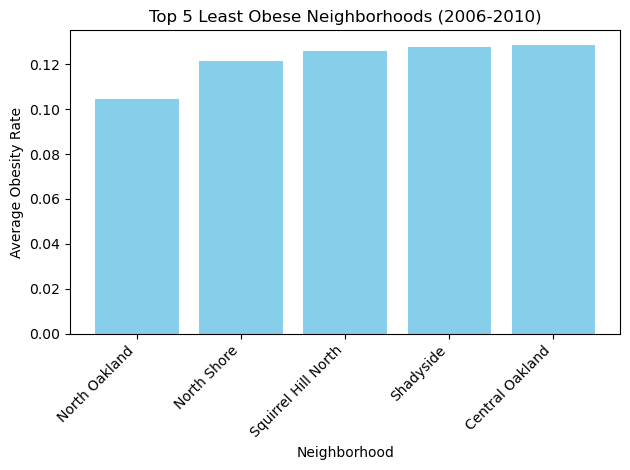

In [3]:
import matplotlib.pyplot as plt

least_obese = neighborhood_obesity.sort_values(by='Average Obesity Rate').head(5)

plt.bar(least_obese['Neighborhood'], least_obese['Average Obesity Rate'], color='skyblue')
plt.xlabel('Neighborhood')
plt.ylabel('Average Obesity Rate')
plt.title('Top 5 Least Obese Neighborhoods (2006-2010)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

## Calculate and Show the Specific Comparison Values

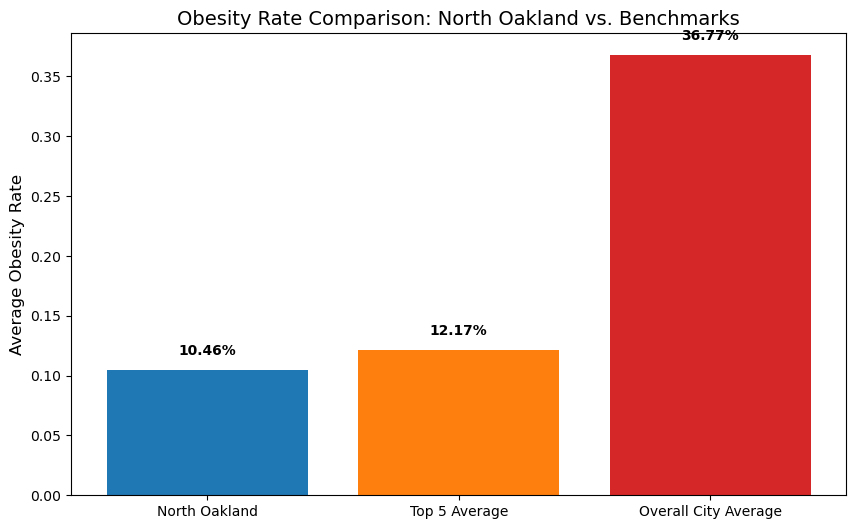

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('obesity-ac-2006-2010censustracts.csv')
neighborhood_stats = df.dropna(subset=['City Neighborhood']).groupby('City Neighborhood')['2006-2010 estimate of obesity'].mean().reset_index()
neighborhood_stats.columns = ['Neighborhood', 'Obesity Rate']

# North Oakland Average Obesity Rate
north_oak_rate = neighborhood_stats[neighborhood_stats['Neighborhood'].str.lower() == 'north oakland']['Obesity Rate'].values[0]

# Top 5 Least Obese Neighborhood Average Obesity Rate
top_5_avg = neighborhood_stats.sort_values(by='Obesity Rate').head(5)['Obesity Rate'].mean()

# Allegheny County Average Obesity Rate
total_avg = neighborhood_stats['Obesity Rate'].mean()


labels = ['North Oakland', 'Top 5 Average', 'Overall City Average']
values = [north_oak_rate, top_5_avg, total_avg]
colors = ['#1f77b4', '#ff7f0e', '#d62728'] # Blue, Orange, Red

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=colors)

plt.title('Obesity Rate Comparison: North Oakland vs. Benchmarks', fontsize=14)
plt.ylabel('Average Obesity Rate', fontsize=12)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2%}', 
             ha='center', va='bottom', fontweight='bold')

plt.show()

## Obesity Rate Differences in Numbers

In [6]:
df = pd.read_csv('obesity-ac-2006-2010censustracts.csv')
neighborhood_stats = df.dropna(subset=['City Neighborhood']).groupby('City Neighborhood')['2006-2010 estimate of obesity'].mean().reset_index()
neighborhood_stats.columns = ['Neighborhood', 'Obesity Rate']

# 1. Get North Oakland's rate
north_oak_rate = neighborhood_stats[neighborhood_stats['Neighborhood'].str.lower() == 'north oakland']['Obesity Rate'].values[0]

# 2. Get average of top 5 healthiest (lowest obesity) neighborhoods
top_5_avg = neighborhood_stats.sort_values(by='Obesity Rate').head(5)['Obesity Rate'].mean()

# 3. Get average of all neighborhoods in the dataset
total_avg = neighborhood_stats['Obesity Rate'].mean()

# Calculate differences in percentage points
diff_top_5_pp = (north_oak_rate - top_5_avg) * 100
diff_city_avg_pp = (north_oak_rate - total_avg) * 100

# Output the results
print("-" * 35)
print(f"Diff (vs. Top 5):         {diff_top_5_pp:.2f} percentage points")
print(f"Diff (vs. City Avg):      {diff_city_avg_pp:.2f} percentage points")

-----------------------------------
Diff (vs. Top 5):         -1.71 percentage points
Diff (vs. City Avg):      -26.31 percentage points


Number of Speed Humps by Neighborhood
---------------

The number of speed humps in a neighborhood is a tangible metric that shows how safe this neighborhood is.

Setting Up the Data
----
___

Importing the libraries

In [1]:
import pandas as pd
import matplotlib as plt

Opening the data

In [2]:
speed_humps = pd.read_csv("speed_humps.csv", index_col="hump_id")
speed_humps.head(5)

,_id,id,locator_address_number,locator_street,pavement,speed_hump_material,neighborhood,council_district,ward,tract,public_works_division,pli_division,police_zone,fire_zone,latitude,longitude
hump_id,,,,,,,,,,,,,,,,
1,1,430808404,4337.0,Saline St,9257,Asphalt,Squirrel Hill South,5,14,42003141400,3,14,4,2-15,40.419835,-79.926062
2,34,1520886592,NaN,Summerset Dr,15346,NaN,Squirrel Hill South,5,14,42003141400,3,14,4,2-20,40.425040,-79.912040
3,67,858537521,511.0,Gold Way,1755,Asphalt,North Oakland,6,5,42003562000,3,5,4,2-23,40.456746,-79.954521
4,68,297775878,547.0,Gold Way,1755,Asphalt,North Oakland,6,5,42003562000,3,5,4,2-23,40.457333,-79.954899
5,69,1061197751,593.0,Gold Way,1755,Asphalt,North Oakland,6,5,42003562000,3,5,4,2-23,40.458061,-79.955355


We just need the number of the humps, so we get rid of the columns that give us extra information

In [3]:
speed_humps.drop("_id", axis=1, inplace=True)
speed_humps.drop("id", axis=1, inplace=True)
speed_humps.drop("locator_street", axis=1, inplace=True)
speed_humps.drop("pavement", axis=1, inplace=True)
speed_humps.drop("speed_hump_material", axis=1, inplace=True)
speed_humps.drop("locator_address_number", axis=1, inplace=True)
speed_humps.drop("council_district", axis=1, inplace=True)
speed_humps.drop("ward", axis=1, inplace=True)
speed_humps.drop("tract", axis=1, inplace=True)
speed_humps.drop("public_works_division", axis=1, inplace=True)
speed_humps.drop("pli_division", axis=1, inplace=True)
speed_humps.drop("police_zone", axis=1, inplace=True)
speed_humps.drop("fire_zone", axis=1, inplace=True)
speed_humps.drop("latitude", axis=1, inplace=True)
speed_humps.drop("longitude", axis=1, inplace=True)

Now let's learn how many humps there are in every neighborhood and leave only top 10 of them

In [4]:
counts = speed_humps["neighborhood"].value_counts().head(10)

Making a plot!

<Axes: xlabel='neighborhood'>

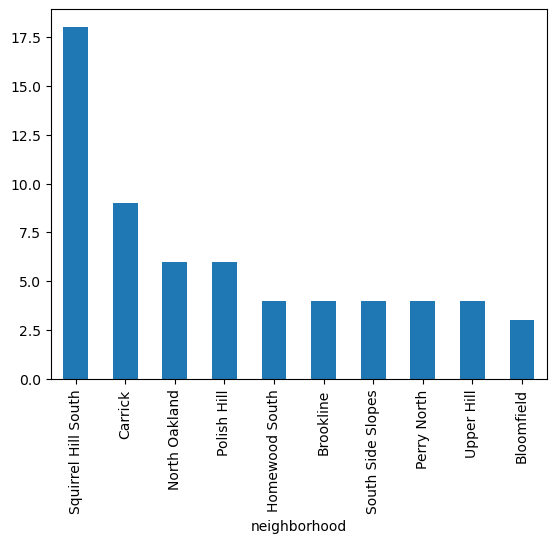

In [5]:
counts.plot(kind="bar")

Key Findings (Conclusion)
-
______________

Counting the mean value for all the neighborhoods and presenting the data as a table

In [6]:
average = counts.mean()

table = counts.reset_index()
table.columns = ["Neighborhood", "Total number of speed humps"]

table["Difference from average"] = table["Total number of speed humps"] - average

table = table.sort_values(by="Total number of speed humps", ascending=False)
print(table)

          Neighborhood  Total number of speed humps  Difference from average
0  Squirrel Hill South                           18                     11.8
1              Carrick                            9                      2.8
2        North Oakland                            6                     -0.2
3          Polish Hill                            6                     -0.2
4       Homewood South                            4                     -2.2
5            Brookline                            4                     -2.2
6    South Side Slopes                            4                     -2.2
7          Perry North                            4                     -2.2
8           Upper Hill                            4                     -2.2
9           Bloomfield                            3                     -3.2


Above the neighborhoods with the most speed humps are shown

Median Age of Death By Neighborhood
---------------
_____

The median age of death clearly demonstrates how healthy a neighborhood is, so it is an important factor to consider (maybe even the most important) when deciding on the healthiest neighborhood.

Setting Up the Data
----
___

First, let's import the libraries we need.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

Now, let's check out our data and make sure everything is in order.

In [4]:
data = pd.read_csv("median_death_neighborhoods.csv")
data.head(10)

,_id,NEIGHBORHOOD,BLACKdeaths,Black MD AGE AT DEATH,WHITEdeaths,White MD AGE AT DEATH,TOTALdeaths*,TOTAL MD AGE AT DEATH
0,1,SOUTH SHORE,0.0,0.0,0.0,0.0,0.0,0.0
1,2,CHATEAU,0.0,0.0,2.0,NaN,2.0,NaN
2,3,NORTH SHORE,0.0,0.0,4.0,NaN,5.0,80.0
3,4,ALLEGHENY WEST,3.0,NaN,4.0,NaN,8.0,65.0
4,5,SAINT CLAIR,5.0,67.5,5.0,67.5,10.0,67.5
5,6,WEST END,5.0,76.7,9.0,78.0,14.0,77.5
6,7,ESPLEN,3.0,NaN,13.0,72.5,16.0,71.7
7,8,ARLINGTON HEIGHTS,10.0,55.0,7.0,72.5,17.0,63.7
8,9,STRIP DISTRICT,7.0,76.7,12.0,70.0,19.0,72.5
9,10,FAIRYWOOD,11.0,62.5,9.0,42.5,21.0,53.3


Now, the neighborhoods with less than 20 recorded deaths probably won't give us a very accurate estimate. Let's eliminate these from our data.

In [5]:
data = data[data["TOTALdeaths*"] > 20]
data.head(10)

,_id,NEIGHBORHOOD,BLACKdeaths,Black MD AGE AT DEATH,WHITEdeaths,White MD AGE AT DEATH,TOTALdeaths*,TOTAL MD AGE AT DEATH
9,10,FAIRYWOOD,11.0,62.5,9.0,42.5,21.0,53.3
10,11,HAYS,1.0,NaN,23.0,78.9,24.0,78.3
11,12,MOUNT OLIVER NEIGHBORHOOD,9.0,67.5,17.0,80.0,26.0,75.0
12,13,EAST CARNEGIE,9.0,72.5,18.0,81.0,27.0,80.0
13,14,REGENT SQUARE,1.0,NaN,27.0,75.8,28.0,76.7
14,15,CALIFORNIA-KIRKBRIDE,16.0,70.0,10.0,70.0,30.0,69.3
15,16,CHARTIERS CITY,20.0,70.0,15.0,81.2,35.0,76.9
16,17,FRIENDSHIP,15.0,66.2,24.0,73.0,41.0,71.1
17,18,BLUFF,18.0,71.7,24.0,69.0,42.0,70.0
18,19,ALLEGHENY CENTER,21.0,63.3,23.0,86.2,46.0,81.7


This looks better. Now we only include the neighborhoods where we have enough data to make a reasonable estimate.

Analyzing the Data
-----
___

Let's get the 10 neighborhoods with the highest median age of death, and then put them into a cleaner dataframe.

In [6]:
sorted_data = data.sort_values(by="TOTAL MD AGE AT DEATH", ascending=False)
sorted_data = sorted_data[["NEIGHBORHOOD", "TOTAL MD AGE AT DEATH"]]
sorted_data.head(10)

,NEIGHBORHOOD,TOTAL MD AGE AT DEATH
89,SQUIRREL HILL SOUTH,85.9
76,NORTH OAKLAND,85.6
71,BANKSVILLE,85.5
53,POINT BREEZE,85.1
68,SQUIRREL HILL NORTH,85.0
20,CENTRAL OAKLAND,84.0
28,NEW HOMESTEAD,83.4
27,SWISSHELM PARK,83.1
77,OVERBROOK,82.2
83,SHADYSIDE,82.1


That was simple! We now have our top 10 neighborhoods in terms of median age of death.
But, since that was so simple, I feel like we should do some more analysis.
So let's see *how* much better they are than average.

In [7]:
ave = sorted_data["TOTAL MD AGE AT DEATH"].mean()
sorted_data["DIFFERENCE FROM AVERAGE"] = sorted_data["TOTAL MD AGE AT DEATH"] - ave
sorted_data.head(10)

,NEIGHBORHOOD,TOTAL MD AGE AT DEATH,DIFFERENCE FROM AVERAGE
89,SQUIRREL HILL SOUTH,85.9,9.806173
76,NORTH OAKLAND,85.6,9.506173
71,BANKSVILLE,85.5,9.406173
53,POINT BREEZE,85.1,9.006173
68,SQUIRREL HILL NORTH,85.0,8.906173
20,CENTRAL OAKLAND,84.0,7.906173
28,NEW HOMESTEAD,83.4,7.306173
27,SWISSHELM PARK,83.1,7.006173
77,OVERBROOK,82.2,6.106173
83,SHADYSIDE,82.1,6.006173


9.8 years is a significant difference! Imagine where you were in the last 10 years, and how much you've grown since then, and how much more you could grow with an extra 10 years... maybe we should all move to Squirrel Hill South... we're getting too philosophical. The difference isn't mind-blowing, but it is quite significant.

Something Extra
-----
____

Since this dataset came with racial data, I decided to investigate whether there are racial disparities, and if so, how significant they are.

In [8]:
racial_data = data
racial_data["DIFFERENCE BY RACE"] = racial_data["White MD AGE AT DEATH"] - racial_data["Black MD AGE AT DEATH"]
racial_data = racial_data[racial_data["DIFFERENCE BY RACE"] == racial_data["DIFFERENCE BY RACE"]] # removing NaN values

racial_data = racial_data[racial_data["Black MD AGE AT DEATH"] != 0] # otherwise we get extremely high values (70+) which are misleading.
racial_data = racial_data[racial_data["White MD AGE AT DEATH"] != 0]

racial_data = racial_data.sort_values(by="DIFFERENCE BY RACE", ascending=False)
racial_data.head(10)


,_id,NEIGHBORHOOD,BLACKdeaths,Black MD AGE AT DEATH,WHITEdeaths,White MD AGE AT DEATH,TOTALdeaths*,TOTAL MD AGE AT DEATH,DIFFERENCE BY RACE
48,49,TROY HILL/HERR'S ISLAND,15.0,42.5,134.0,73.8,151.0,70.3,31.3
39,40,UPPER LAWRENCEVILLE,8.0,48.3,111.0,75.5,119.0,73.7,27.2
57,58,CRAFTON HEIGHTS,27.0,51.2,159.0,76.0,187.0,73.5,24.8
84,85,BEECHVIEW,35.0,55.8,398.0,80.2,434.0,78.9,24.4
18,19,ALLEGHENY CENTER,21.0,63.3,23.0,86.2,46.0,81.7,22.9
34,35,ARLINGTON,14.0,55.0,81.0,76.1,96.0,73.7,21.1
51,52,WESTWOOD,12.0,58.3,159.0,77.8,173.0,77.0,19.5
67,68,SOUTHSIDE SLOPES,9.0,58.7,208.0,77.9,220.0,77.2,19.2
53,54,POINT BREEZE,13.0,66.7,158.0,85.7,175.0,85.1,19.0
87,88,CARRICK,35.0,59.4,622.0,77.0,678.0,75.9,17.6


There are some pretty huge differences here. These are even more significant than the differences between neighborhoods. Let's get these on a plot.

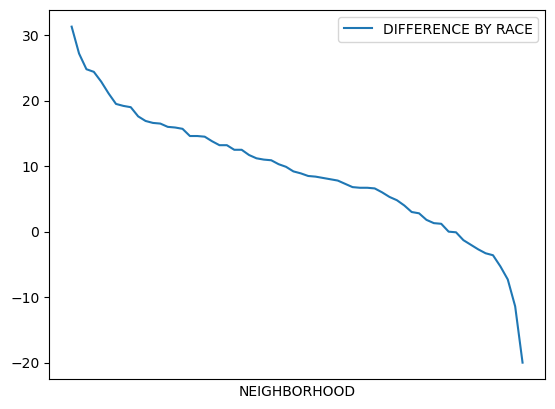

In [9]:
racial_data.plot(x='NEIGHBORHOOD', y='DIFFERENCE BY RACE')
plt.xticks([])
plt.show()

For a vast majority of the neighborhoods (looks to be over 80%), white people live longer than Black people. And for about 50% of neighborhoods, the difference is over 10 years; this is quite shocking. How about we actually calculate these percentages instead of eyeballing it?

In [10]:
count = len(racial_data[racial_data['DIFFERENCE BY RACE'] > 0])
perc = count / len(racial_data) * 100
perc = round(perc, 2)
print("Percent of neighborhoods where white people live longer than Black people: " + str(perc))
count2 = len(racial_data[racial_data['DIFFERENCE BY RACE'] > 10])
med = racial_data['DIFFERENCE BY RACE'].median()
med = round(med, 2)
print("In half of all neighborhoods, this difference is over " + str(med) + " YEARS.")

Percent of neighborhoods where white people live longer than Black people: 82.26
In half of all neighborhoods, this difference is over 9.05 YEARS.


Key Findings (Conclusion)
-
______________

The 10 neighborhoods with the highest median age of death, as well as how much above average they are, are shown below:

In [11]:
sorted_data.head(10)

,NEIGHBORHOOD,TOTAL MD AGE AT DEATH,DIFFERENCE FROM AVERAGE
89,SQUIRREL HILL SOUTH,85.9,9.806173
76,NORTH OAKLAND,85.6,9.506173
71,BANKSVILLE,85.5,9.406173
53,POINT BREEZE,85.1,9.006173
68,SQUIRREL HILL NORTH,85.0,8.906173
20,CENTRAL OAKLAND,84.0,7.906173
28,NEW HOMESTEAD,83.4,7.306173
27,SWISSHELM PARK,83.1,7.006173
77,OVERBROOK,82.2,6.106173
83,SHADYSIDE,82.1,6.006173


## Conclusion - How does North Oakland differ from our personal favorite neighborhood?

Jess - My personal favorite allegheny county neighborhood is South Oakland because that's the neighborhood I have lived in for the past three years while here at Pitt. I think in terms of health and safety it is pretty similar to North Oalkand as it is near campus and several job opportunities, meaning it also has high walkability and is close to recreational areas like Schenley park. On the other hand, there might be a higher amount of junk food consumption due to many near by fast food options closert to us. I would say South Oakland is much more of a packed, high energy, student hub while North Oakland is more calm with 

Patton - My favorite neighborhood in Allegheny County is Aspinwall, where I lived for about 10 years. It has a cool Fireman's park with a big hill, but these are reasons I like it that aren't really related to health, which is what we are discussing. From my personal experience, I have not seen very many obese people around, and I think they have gotten rid of every speed bump! However, some of the roads are so bad you can't help but drive slow (or destroy your tires). North Oakland is definitely both more urban and scenic than Aspinwall, and it clearly is healthier according to the data. Now that I think about it, North Oakland is probably much better than Aspinwall in almost every way, but since I grew up in Aspinwall, I view it more favorably.